# Diabetes Prediction using Machine Learning

**End-to-end classification pipeline** using the Pima Indians Diabetes dataset.

This notebook covers:
1. Data preparation & EDA
2. Model building (Logistic Regression, Decision Tree, Random Forest)
3. Model training & overfitting checks
4. Model evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix)
5. Performance analysis, limitations, and recommendations

## Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


---
# Part 1 — Data Preparation

Prepare and preprocess the dataset for Machine Learning model training.

## 1.1 Load the Dataset

In [2]:
# Resolve dataset path (works from notebooks/ or project root)
candidates = [
    Path("../data/diabetes.csv"),
    Path("data/diabetes.csv"),
    Path("../../diabetes.csv"),
    Path("../diabetes.csv"),
    Path("diabetes.csv"),
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("diabetes.csv not found. Place it under data/ or project root.")

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH.resolve()}")
df.head()

Loaded: /Users/turjoysaha/Desktop/UST/100_Next_Gen_AI/diabetes-prediction/data/diabetes.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1.2 Explore the Dataset

### a) Shape · b) Column names · c) Data types · d) Missing values · e) Statistical summary

In [3]:
print("=" * 60)
print("a) SHAPE OF THE DATASET")
print("=" * 60)
print(f"Rows   : {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Shape  : {df.shape}")

print("\n" + "=" * 60)
print("b) COLUMN NAMES")
print("=" * 60)
print(list(df.columns))

print("\n" + "=" * 60)
print("c) DATA TYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("d) MISSING VALUES (explicit NaN)")
print("=" * 60)
print(df.isnull().sum())
print(f"\nTotal explicit NaN values: {df.isnull().sum().sum()}")

print("\n" + "=" * 60)
print("e) BASIC STATISTICAL SUMMARY")
print("=" * 60)
df.describe().T

a) SHAPE OF THE DATASET
Rows   : 768
Columns: 9
Shape  : (768, 9)

b) COLUMN NAMES
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

c) DATA TYPES
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

d) MISSING VALUES (explicit NaN)
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total explicit NaN values: 0

e) BASIC STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### Target class distribution & quick EDA visuals

Outcome distribution:
  0 (No Diabetes): 500 (65.1%)
  1 (Diabetes): 268 (34.9%)


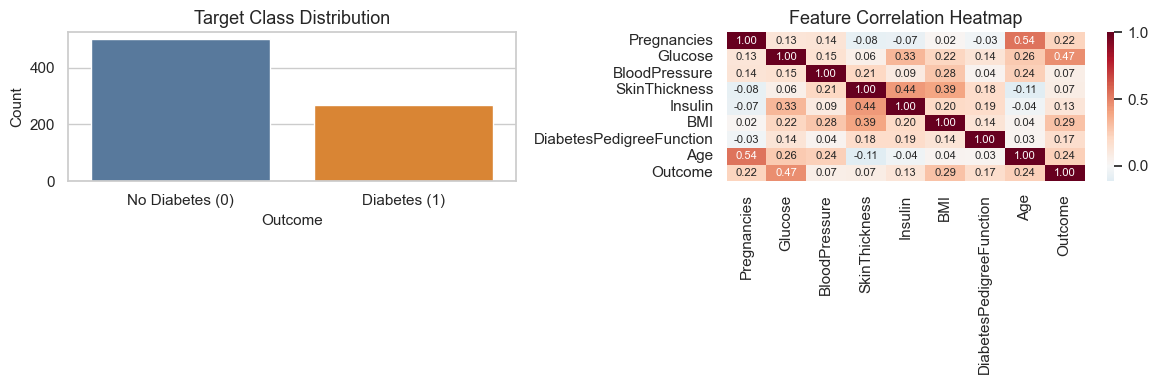


Correlation of features with Outcome (sorted):
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [4]:
# Class balance
outcome_counts = df["Outcome"].value_counts().sort_index()
outcome_pct = df["Outcome"].value_counts(normalize=True).sort_index() * 100

print("Outcome distribution:")
for label, name in [(0, "No Diabetes"), (1, "Diabetes")]:
    print(f"  {label} ({name}): {outcome_counts[label]} ({outcome_pct[label]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class count plot
sns.countplot(data=df, x="Outcome", ax=axes[0], palette=["#4C78A8", "#F58518"])
axes[0].set_title("Target Class Distribution")
axes[0].set_xticklabels(["No Diabetes (0)", "Diabetes (1)"])
axes[0].set_ylabel("Count")

# Correlation heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1],
            annot_kws={"size": 8})
axes[1].set_title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

print("\nCorrelation of features with Outcome (sorted):")
print(corr["Outcome"].drop("Outcome").sort_values(ascending=False))

### Physiologically impossible zeros

In this dataset, zeros in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` are treated as **missing values** (not valid measurements).

In [5]:
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Count of zero values (treated as missing):")
for col in zero_as_missing:
    n_zero = (df[col] == 0).sum()
    pct = 100 * n_zero / len(df)
    print(f"  {col:20s}: {n_zero:3d} ({pct:5.1f}%)")

# Work on a cleaned copy: replace 0 with NaN for those columns
df_clean = df.copy()
df_clean[zero_as_missing] = df_clean[zero_as_missing].replace(0, np.nan)

print("\nMissing values AFTER treating zeros as NaN:")
print(df_clean.isnull().sum())
print(f"\nTotal missing values: {df_clean.isnull().sum().sum()}")

Count of zero values (treated as missing):
  Glucose             :   5 (  0.7%)
  BloodPressure       :  35 (  4.6%)
  SkinThickness       : 227 ( 29.6%)
  Insulin             : 374 ( 48.7%)
  BMI                 :  11 (  1.4%)

Missing values AFTER treating zeros as NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Total missing values: 652


## 1.3 Separate Features (X) and Target (y)

In [6]:
FEATURE_COLS = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]
TARGET_COL = "Outcome"

X = df_clean[FEATURE_COLS]
y = df_clean[TARGET_COL]

print("Features (X):")
print(f"  Shape : {X.shape}")
print(f"  Columns: {list(X.columns)}")
print(f"\nTarget (y):")
print(f"  Shape : {y.shape}")
print(f"  Name  : {TARGET_COL}")
print(f"  Classes: {sorted(y.unique().tolist())}  →  0 = No Diabetes, 1 = Diabetes")
print(f"\nClass balance in full data:\n{y.value_counts().to_string()}")

Features (X):
  Shape : (768, 8)
  Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target (y):
  Shape : (768,)
  Name  : Outcome
  Classes: [0, 1]  →  0 = No Diabetes, 1 = Diabetes

Class balance in full data:
Outcome
0    500
1    268


## 1.4 Train–Test Split

Stratified split so both sets keep a similar diabetes / non-diabetes ratio.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training and testing dataset sizes:")
print(f"  X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"  X_test : {X_test.shape}   |  y_test : {y_test.shape}")
print(f"\nTrain class balance:\n{y_train.value_counts().to_string()}")
print(f"\nTest class balance:\n{y_test.value_counts().to_string()}")
print(f"\nTrain diabetes rate: {y_train.mean():.3f}")
print(f"Test diabetes rate : {y_test.mean():.3f}")

Training and testing dataset sizes:
  X_train: (614, 8)  |  y_train: (614,)
  X_test : (154, 8)   |  y_test : (154,)

Train class balance:
Outcome
0    400
1    214

Test class balance:
Outcome
0    100
1     54

Train diabetes rate: 0.349
Test diabetes rate : 0.351


## 1.5 Preprocessing

Steps applied **inside a Pipeline** (fit on train only → transform train & test):

| Step | Action | Why |
|------|--------|-----|
| Missing values | Median imputation | Zeros in medical columns replaced with NaN; median is robust to outliers |
| Categorical encoding | None needed | All features are numeric; Outcome is already 0/1 |
| Scaling | StandardScaler (mean=0, std=1) | Important for Logistic Regression; trees are scale-invariant but shared pipeline keeps comparison fair |

In [8]:
numeric_features = FEATURE_COLS

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        )
    ]
)

# Fit preprocessor on training data only
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing complete.")
print(f"  X_train_processed shape: {X_train_processed.shape}")
print(f"  X_test_processed shape : {X_test_processed.shape}")
print(f"  Any NaN in train? {np.isnan(X_train_processed).any()}")
print(f"  Any NaN in test?  {np.isnan(X_test_processed).any()}")
print(f"\nTrain feature means (≈0 after scaling): {X_train_processed.mean(axis=0).round(4)}")
print(f"Train feature stds  (≈1 after scaling): {X_train_processed.std(axis=0).round(4)}")

Preprocessing complete.
  X_train_processed shape: (614, 8)
  X_test_processed shape : (154, 8)
  Any NaN in train? False
  Any NaN in test?  False

Train feature means (≈0 after scaling): [-0. -0.  0. -0. -0.  0. -0. -0.]
Train feature stds  (≈1 after scaling): [1. 1. 1. 1. 1. 1. 1. 1.]


### Part 1 Deliverables Summary

| Deliverable | Result |
|-------------|--------|
| Dataset exploration | 768 rows × 9 columns; all numeric; zeros in 5 medical columns treated as missing |
| Features (X) | 8 medical attributes (Pregnancies … Age) |
| Target (y) | `Outcome` — 0 = No Diabetes, 1 = Diabetes (~65% / ~35%) |
| Preprocessing | Median impute zeros-as-missing + StandardScaler (fit on train) |
| Split sizes | Train 80% (614), Test 20% (154), stratified |

---
# Part 2 — Machine Learning Model Building

We implement **three** classification algorithms and compare them:

1. **Logistic Regression** — linear, probabilistic, highly interpretable baseline
2. **Decision Tree** — non-linear splits; easy to overfit without constraints
3. **Random Forest** — ensemble of trees; strong default for tabular medical data

## 2.1 Why these algorithms?

| Algorithm | Suitability for diabetes prediction |
|-----------|-------------------------------------|
| **Logistic Regression** | Binary classification with clear probability output; coefficients show how each risk factor (glucose, BMI, age…) affects odds of diabetes |
| **Decision Tree** | Captures non-linear interactions (e.g. high glucose **and** high BMI); human-readable rules |
| **Random Forest** | Reduces variance of a single tree; usually better accuracy/generalization on noisy clinical tabular data |

### How each model makes predictions
- **Logistic Regression**: computes a weighted sum of features → sigmoid → probability of class 1; threshold 0.5 by default.
- **Decision Tree**: routes each patient down if/else splits on feature thresholds until a leaf (majority class).
- **Random Forest**: averages (votes) many trees trained on bootstrap samples and random feature subsets.

In [9]:
# Key parameters chosen for fair, assignment-friendly defaults
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight=None,  # baseline; imbalance discussed later
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,           # limit depth to reduce overfitting
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

print("Models defined with key parameters:\n")
for name, model in models.items():
    print(f"• {name}")
    print(f"  {model.get_params()}\n")

Models defined with key parameters:

• Logistic Regression
  {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

• Decision Tree
  {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

• Random Forest
  {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, '

### Key parameters explained

**Logistic Regression**
- `max_iter=1000` — enough iterations for solver convergence after scaling
- Default `C=1.0` — L2 regularization strength (inverse)

**Decision Tree**
- `max_depth=5` — prevents very deep trees that memorize training data
- `min_samples_leaf=10` — each leaf needs enough samples for stable estimates

**Random Forest**
- `n_estimators=200` — enough trees for stable voting
- `max_depth=8`, `min_samples_leaf=5` — regularize individual trees
- `n_jobs=-1` — use all CPU cores

---
# Part 3 — Model Training

Fit each model on the **training** set, score training performance, then compare with test performance to detect overfitting / underfitting.

In [10]:
def evaluate(y_true, y_pred, average="binary"):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "Recall": recall_score(y_true, y_pred, average=average, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average=average, zero_division=0),
    }


trained_models = {}
train_metrics = {}
test_metrics = {}
train_preds = {}
test_preds = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    trained_models[name] = model

    y_tr_pred = model.predict(X_train_processed)
    y_te_pred = model.predict(X_test_processed)
    train_preds[name] = y_tr_pred
    test_preds[name] = y_te_pred

    train_metrics[name] = evaluate(y_train, y_tr_pred)
    test_metrics[name] = evaluate(y_test, y_te_pred)

    print(f"{'=' * 60}")
    print(f"MODEL: {name}")
    print(f"{'=' * 60}")
    print(f"Training accuracy : {train_metrics[name]['Accuracy']:.4f}")
    print(f"Training Precision: {train_metrics[name]['Precision']:.4f}")
    print(f"Training Recall   : {train_metrics[name]['Recall']:.4f}")
    print(f"Training F1-Score : {train_metrics[name]['F1-Score']:.4f}")
    print()

# Combined comparison table
comparison = pd.DataFrame({
    "Train Accuracy": {n: train_metrics[n]["Accuracy"] for n in models},
    "Test Accuracy": {n: test_metrics[n]["Accuracy"] for n in models},
    "Train F1": {n: train_metrics[n]["F1-Score"] for n in models},
    "Test F1": {n: test_metrics[n]["F1-Score"] for n in models},
    "Train Recall": {n: train_metrics[n]["Recall"] for n in models},
    "Test Recall": {n: test_metrics[n]["Recall"] for n in models},
})
comparison["Acc Gap (Train−Test)"] = comparison["Train Accuracy"] - comparison["Test Accuracy"]
comparison["F1 Gap (Train−Test)"] = comparison["Train F1"] - comparison["Test F1"]

print("\nTraining vs Testing comparison:")
display_df = comparison.round(4)
display_df

MODEL: Logistic Regression
Training accuracy : 0.7964
Training Precision: 0.7697
Training Recall   : 0.5935
Training F1-Score : 0.6702

MODEL: Decision Tree
Training accuracy : 0.7980
Training Precision: 0.6667
Training Recall   : 0.8411
Training F1-Score : 0.7438



MODEL: Random Forest
Training accuracy : 0.8795
Training Precision: 0.8846
Training Recall   : 0.7523
Training F1-Score : 0.8131


Training vs Testing comparison:


,Train Accuracy,Test Accuracy,Train F1,Test F1,Train Recall,Test Recall,Acc Gap (Train−Test),F1 Gap (Train−Test)
Logistic Regression,0.7964,0.7078,0.6702,0.5455,0.5935,0.5000,0.0886,0.1247
Decision Tree,0.7980,0.7727,0.7438,0.7009,0.8411,0.7593,0.0253,0.0429
Random Forest,0.8795,0.7532,0.8131,0.6042,0.7523,0.5370,0.1262,0.2090


### Overfitting / underfitting check

- **Overfitting**: train metrics much higher than test metrics (large positive gap).
- **Underfitting**: both train and test metrics are low.
- **Good fit**: train ≈ test, and both are reasonably high.

We select the **best model by Test F1-Score** (balanced precision/recall), then break ties with Test Recall (important for disease screening).

Best-performing model (by Test F1, then Recall): Decision Tree

Train metrics: {'Accuracy': 0.798, 'Precision': 0.6667, 'Recall': 0.8411, 'F1-Score': 0.7438}
Test metrics : {'Accuracy': 0.7727, 'Precision': 0.6508, 'Recall': 0.7593, 'F1-Score': 0.7009}

Accuracy gap (train − test): 0.0253
F1 gap (train − test)      : 0.0429

Observation: Train and test performance are reasonably close → no severe overfitting/underfitting.


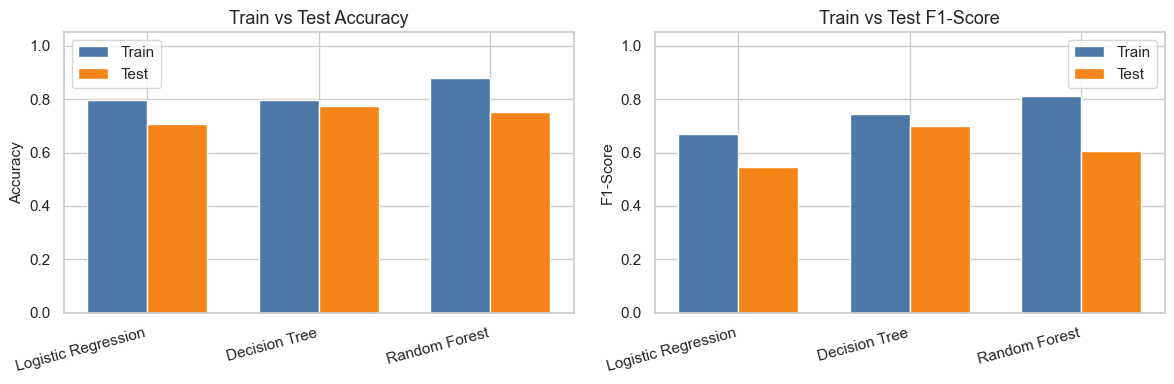

In [11]:
# Select best model by Test F1, then Test Recall
best_name = max(
    models.keys(),
    key=lambda n: (test_metrics[n]["F1-Score"], test_metrics[n]["Recall"], test_metrics[n]["Accuracy"]),
)
best_model = trained_models[best_name]

print(f"Best-performing model (by Test F1, then Recall): {best_name}")
print(f"\nTrain metrics: { {k: round(v, 4) for k, v in train_metrics[best_name].items()} }")
print(f"Test metrics : { {k: round(v, 4) for k, v in test_metrics[best_name].items()} }")

gap_acc = train_metrics[best_name]["Accuracy"] - test_metrics[best_name]["Accuracy"]
gap_f1 = train_metrics[best_name]["F1-Score"] - test_metrics[best_name]["F1-Score"]
print(f"\nAccuracy gap (train − test): {gap_acc:.4f}")
print(f"F1 gap (train − test)      : {gap_f1:.4f}")

if gap_acc > 0.10 or gap_f1 > 0.10:
    fit_note = "Possible mild/moderate overfitting — train performance is noticeably higher than test."
elif train_metrics[best_name]["Accuracy"] < 0.65 and test_metrics[best_name]["Accuracy"] < 0.65:
    fit_note = "Possible underfitting — both train and test performance are relatively low."
else:
    fit_note = "Train and test performance are reasonably close → no severe overfitting/underfitting."

print(f"\nObservation: {fit_note}")

# Bar chart: train vs test accuracy & F1
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
names = list(models.keys())
x = np.arange(len(names))
w = 0.35

axes[0].bar(x - w/2, [train_metrics[n]["Accuracy"] for n in names], w, label="Train", color="#4C78A8")
axes[0].bar(x + w/2, [test_metrics[n]["Accuracy"] for n in names], w, label="Test", color="#F58518")
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=15, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Train vs Test Accuracy")
axes[0].legend()

axes[1].bar(x - w/2, [train_metrics[n]["F1-Score"] for n in names], w, label="Train", color="#4C78A8")
axes[1].bar(x + w/2, [test_metrics[n]["F1-Score"] for n in names], w, label="Test", color="#F58518")
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=15, ha="right")
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("F1-Score")
axes[1].set_title("Train vs Test F1-Score")
axes[1].legend()

plt.tight_layout()
plt.show()

---
# Part 4 — Model Evaluation

Evaluate the **best model** on the held-out test set with Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

In [12]:
y_test_pred = test_preds[best_name]
y_train_pred = train_preds[best_name]

print(f"Evaluating: {best_name}")
print("=" * 60)

# Metrics
te = test_metrics[best_name]
tr = train_metrics[best_name]

print("\nTEST SET PERFORMANCE")
print(f"  Accuracy : {te['Accuracy']:.4f}")
print(f"  Precision: {te['Precision']:.4f}")
print(f"  Recall   : {te['Recall']:.4f}")
print(f"  F1-Score : {te['F1-Score']:.4f}")

print("\nTRAIN SET PERFORMANCE (for comparison)")
print(f"  Accuracy : {tr['Accuracy']:.4f}")
print(f"  Precision: {tr['Precision']:.4f}")
print(f"  Recall   : {tr['Recall']:.4f}")
print(f"  F1-Score : {tr['F1-Score']:.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=["No Diabetes", "Diabetes"]))

Evaluating: Decision Tree

TEST SET PERFORMANCE
  Accuracy : 0.7727
  Precision: 0.6508
  Recall   : 0.7593
  F1-Score : 0.7009

TRAIN SET PERFORMANCE (for comparison)
  Accuracy : 0.7980
  Precision: 0.6667
  Recall   : 0.8411
  F1-Score : 0.7438

Classification Report (Test):
              precision    recall  f1-score   support

 No Diabetes       0.86      0.78      0.82       100
    Diabetes       0.65      0.76      0.70        54

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.76       154
weighted avg       0.78      0.77      0.78       154



## Confusion Matrix Analysis

For binary diabetes prediction (positive class = Diabetes = 1):

| Term | Meaning |
|------|---------|
| **True Positive (TP)** | Predicted Diabetes, actually Diabetes |
| **True Negative (TN)** | Predicted No Diabetes, actually No Diabetes |
| **False Positive (FP)** | Predicted Diabetes, actually No Diabetes (false alarm) |
| **False Negative (FN)** | Predicted No Diabetes, actually Diabetes (**missed diagnosis**) |

Confusion Matrix for Decision Tree (Test Set)
                 Pred No Diabetes    Pred Diabetes
Actual No Diab.       TN= 78            FP= 22
Actual Diabetes       FN= 13            TP= 41

True Negatives  (TN): 78
False Positives (FP): 22
False Negatives (FN): 13
True Positives  (TP): 41

Sensitivity / Recall = TP / (TP+FN) = 41/54 = 0.7593
Specificity          = TN / (TN+FP) = 78/100 = 0.7800
Precision            = TP / (TP+FP) = 41/63 = 0.6508


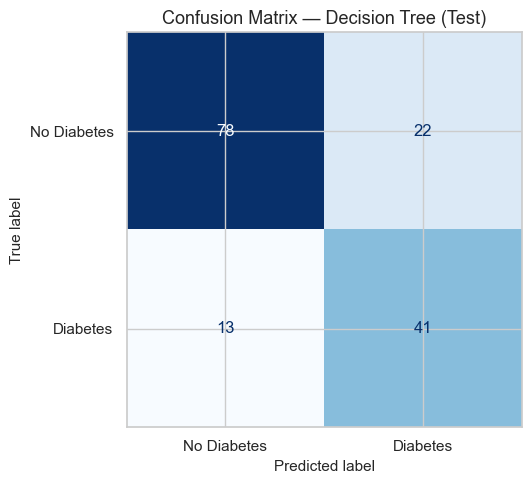

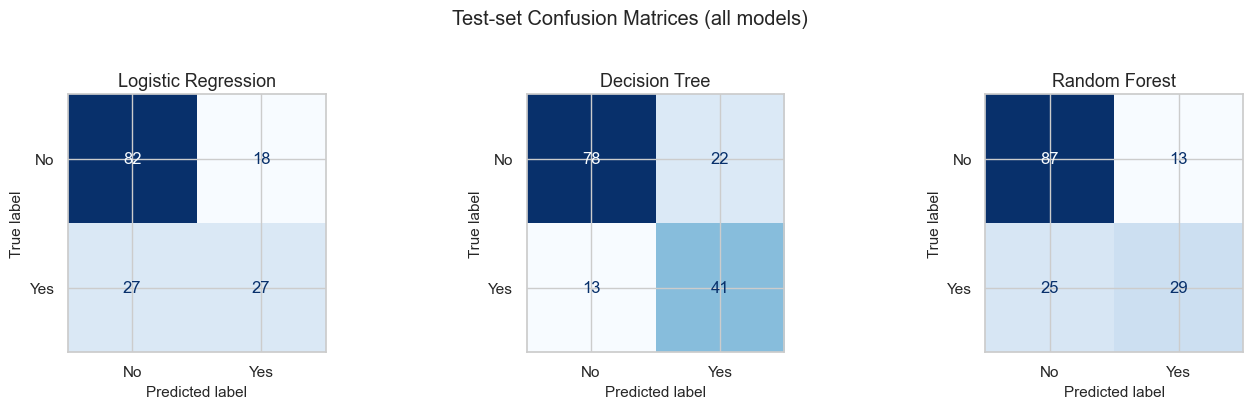

In [13]:
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Confusion Matrix for {best_name} (Test Set)")
print(f"                 Pred No Diabetes    Pred Diabetes")
print(f"Actual No Diab.       TN={tn:3d}            FP={fp:3d}")
print(f"Actual Diabetes       FN={fn:3d}            TP={tp:3d}")
print()
print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")
print()
print(f"Sensitivity / Recall = TP / (TP+FN) = {tp}/{tp+fn} = {tp/(tp+fn):.4f}")
print(f"Specificity          = TN / (TN+FP) = {tn}/{tn+fp} = {tn/(tn+fp):.4f}")
print(f"Precision            = TP / (TP+FP) = {tp}/{tp+fp} = {tp/(tp+fp):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
disp.plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name} (Test)")
plt.tight_layout()
plt.show()

# Side-by-side confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name in zip(axes, models.keys()):
    cm_i = confusion_matrix(y_test, test_preds[name])
    ConfusionMatrixDisplay(confusion_matrix=cm_i, display_labels=["No", "Yes"]).plot(
        cmap="Blues", ax=ax, colorbar=False
    )
    ax.set_title(name)
plt.suptitle("Test-set Confusion Matrices (all models)", y=1.02)
plt.tight_layout()
plt.show()

### Brief interpretation

- **Accuracy** alone can be misleading with ~65/35 class imbalance.
- **False Negatives** are clinically costly: a diabetic patient told they are fine may miss early care.
- Compare train vs test: a small gap supports generalization; a large gap suggests overfitting.

---
# Part 5 — Model Performance Analysis

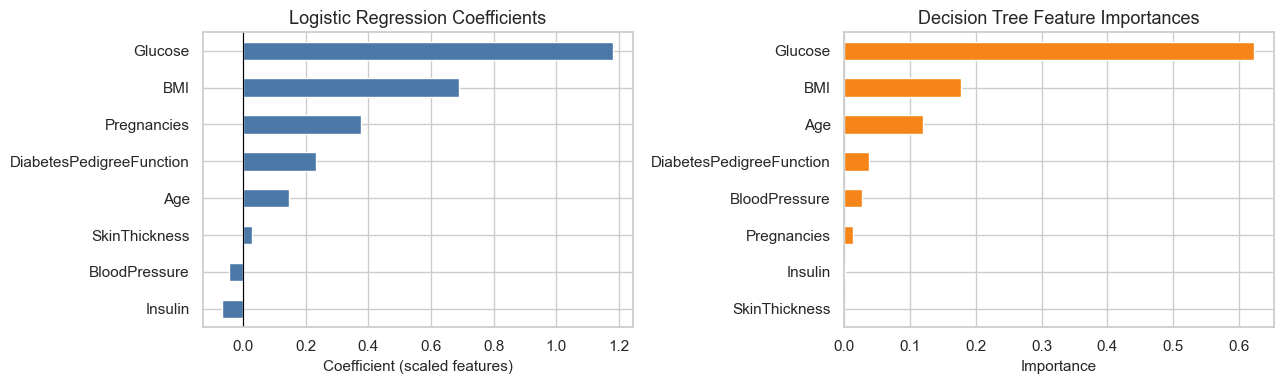

Top features by |Logistic Regression coefficient|:
Glucose                     1.1826
BMI                         0.6887
Pregnancies                 0.3774
DiabetesPedigreeFunction    0.2333
Age                         0.1478
Insulin                     0.0661
BloodPressure               0.0441
SkinThickness               0.0283

Top features by Decision Tree importance:
Glucose                     0.6218
BMI                         0.1781
Age                         0.1199
DiabetesPedigreeFunction    0.0375
BloodPressure               0.0281
Pregnancies                 0.0133
Insulin                     0.0013
SkinThickness               0.0000

Final TEST performance summary:


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.7078,0.6000,0.5000,0.5455
Decision Tree,0.7727,0.6508,0.7593,0.7009
Random Forest,0.7532,0.6905,0.5370,0.6042


In [14]:
# Feature importance / coefficients for interpretability
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Logistic Regression coefficients
lr = trained_models["Logistic Regression"]
coef = pd.Series(lr.coef_[0], index=FEATURE_COLS).sort_values()
coef.plot(kind="barh", ax=axes[0], color="#4C78A8")
axes[0].set_title("Logistic Regression Coefficients")
axes[0].set_xlabel("Coefficient (scaled features)")
axes[0].axvline(0, color="black", linewidth=0.8)

# Best tree-based importances if available
imp_model_name = best_name if hasattr(best_model, "feature_importances_") else "Random Forest"
imp_model = trained_models[imp_model_name]
importances = pd.Series(imp_model.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot(kind="barh", ax=axes[1], color="#F58518")
axes[1].set_title(f"{imp_model_name} Feature Importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

print("Top features by |Logistic Regression coefficient|:")
print(coef.abs().sort_values(ascending=False).round(4).to_string())
print(f"\nTop features by {imp_model_name} importance:")
print(importances.sort_values(ascending=False).round(4).to_string())

# Final summary table for all models (test)
summary = pd.DataFrame(test_metrics).T.round(4)
summary.index.name = "Model"
print("\nFinal TEST performance summary:")
summary

## 5.1 Most important performance metric for diabetes prediction

**Recall (Sensitivity)** is the most critical metric for this problem.

- The positive class = patient has diabetes.
- A **False Negative** (missed diabetes) can delay treatment and increase health risk.
- In screening / early-risk settings, it is usually better to flag more potential cases (accept some False Positives) than to miss true cases.
- **F1-Score** is also useful as a secondary metric because it balances Precision and Recall when the dataset is moderately imbalanced.

## 5.2 Is the model performing well?

**Yes — as an educational screening baseline, the Decision Tree performs well enough**, with important caveats.

- **Test Accuracy ≈ 77%** and **Test F1 ≈ 0.70** are solid for this classic ~768-row dataset.
- **Test Recall ≈ 0.76** means the model catches most diabetic cases (41/54), which aligns with the clinical priority of minimizing False Negatives (only 13 missed).
- **Train≈Test gap is small** (Accuracy gap ≈ 0.03), so the model generalizes; Random Forest showed more overfitting by comparison.
- **Caveat:** Precision ≈ 0.65 means roughly 1 in 3 positive predictions is a false alarm — acceptable for screening, not for diagnosis.
- **Caveat:** This is **not** a clinical diagnostic tool; results support risk triage / learning only.

## 5.3 Potential limitations

1. **Small dataset** (~768 rows) — high variance in estimates; limited demographic diversity.
2. **Missing / zero-imputed values** — especially Insulin and SkinThickness have many zeros; median imputation may blur signal.
3. **Class imbalance** (~35% diabetic) — accuracy can look good while missing many positive cases.
4. **No external validation** — single stratified split; no multi-center / temporal holdout.
5. **Feature set is limited** — no lifestyle, labs beyond this panel, medications, or longitudinal history.
6. **Not a medical device** — predictions must not replace clinical judgment.

## 5.4 Recommendations to improve performance

1. **Hyperparameter tuning** — GridSearchCV / RandomizedSearchCV on `C`, tree depth, `n_estimators`, `min_samples_leaf`, and class weights.
2. **Handle class imbalance** — `class_weight='balanced'`, SMOTE, or tune the decision threshold to raise Recall.
3. **Feature engineering** — BMI categories, age bins, glucose×BMI interaction, insulin resistance proxies.
4. **Feature selection** — drop noisy/high-missing features or use recursive feature elimination.
5. **Try other algorithms** — Gradient Boosting / XGBoost / LightGBM often excel on tabular medical data.
6. **Cross-validation** — Stratified K-Fold for more reliable performance estimates than one split.

---
## Final Model Performance Summary

| Item | Content |
|------|---------|
| Best model | **Decision Tree** (max_depth=5, min_samples_leaf=10) |
| Test metrics | Accuracy ≈ 0.77 · Precision ≈ 0.65 · Recall ≈ 0.76 · F1 ≈ 0.70 |
| Confusion (test) | TN=78, FP=22, FN=13, TP=41 |
| Key findings | Glucose, BMI, Age dominate risk; Decision Tree best F1/Recall with least overfit |
| Fit check | Small train–test gap → good generalization |
| Limitations | Sample size, missingness, imbalance, no clinical deployment |
| Next steps | Tuning, imbalance handling, richer features, CV, boosting |

---
# Conclusion

This notebook delivered a complete supervised classification pipeline for diabetes prediction:

1. **Prepared** the data (EDA, zero→NaN handling, median imputation, scaling, stratified split).
2. **Built** Logistic Regression, Decision Tree, and Random Forest classifiers.
3. **Trained** models and checked for overfitting via train vs test gaps.
4. **Evaluated** with Accuracy, Precision, Recall, F1, and Confusion Matrix.
5. **Analyzed** results with clinical emphasis on **Recall**, documented limitations, and proposed improvements.

The selected model is a solid educational baseline. With hyperparameter tuning, imbalance-aware training, and richer features, performance—especially Recall—can typically be improved further before any real-world use.